<a href="https://colab.research.google.com/github/tompopo777/semiconductor-it-rd-impact-on-profit/blob/main/semiconductor_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/Colab Notebooks/Capstone/final_version_2017-2021_semiconductor.csv'
df = pd.read_csv(file_path, low_memory=False)

# df = pd.read_csv('C:\\Users\\leosh\\final_version_2017-2021_semiconductor.csv', low_memory=False)

df

Mounted at /content/drive


,company_name,ni,at,revt,xrd,fyear,lt,ceq,capx,che,...,ROA,IT_Intensity,RD_Intensity,Fiscal_Year,Leverage,CapEx_Intensity,Cash_to_Assets,Sales_Growth,sg_dummy,Firm_Age
0,ADVANCED MICRO DEVICES,43.000,3540.000,5329.000,1160.000,2017,2929.000,611.000,113.000,1187.000,...,0.012147,0.102145,0.327684,2017,4.793781,0.031921,0.335311,0.247425,0,48
1,ADVANCED MICRO DEVICES,337.000,4556.000,6475.000,1434.000,2018,3290.000,1266.000,163.000,1161.000,...,0.073968,0.096804,0.314750,2018,2.598736,0.035777,0.254829,0.215050,0,49
2,ADVANCED MICRO DEVICES,341.000,6028.000,6731.000,1547.000,2019,3201.000,2827.000,217.000,1507.000,...,0.056569,0.084805,0.256636,2019,1.132296,0.035999,0.250000,0.039537,0,50
3,ADVANCED MICRO DEVICES,2490.000,8962.000,9763.000,1983.000,2020,3125.000,5837.000,294.000,2290.000,...,0.277840,0.007893,0.221268,2020,0.535378,0.032805,0.255523,0.450453,0,51
4,ADVANCED MICRO DEVICES,3162.000,12419.000,16434.000,2845.000,2021,4922.000,7497.000,301.000,3608.000,...,0.254610,0.029266,0.229084,2021,0.656529,0.024237,0.290523,0.683294,0,52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,ENPHASE ENERGY INC,-45.192,169.147,286.166,33.157,2017,178.273,-9.126,4.121,29.144,...,-0.267176,0.144863,0.196025,2017,-19.534626,0.024363,0.172300,-0.112914,0,11
141,ENPHASE ENERGY INC,-11.627,339.937,316.159,32.587,2018,332.161,7.776,4.151,106.237,...,-0.034203,0.063985,0.095862,2018,42.716178,0.012211,0.312520,0.104810,0,12
142,ENPHASE ENERGY INC,161.148,713.223,624.333,40.381,2019,441.011,272.212,14.788,296.109,...,0.225943,0.033557,0.056618,2019,1.620101,0.020734,0.415170,0.974744,0,13
143,ENPHASE ENERGY INC,133.995,1200.102,774.425,55.921,2020,716.109,483.993,20.558,679.379,...,0.111653,0.019943,0.046597,2020,1.479585,0.017130,0.566101,0.240404,0,14


In [ ]:
# df["IT_Intensity_z"] = (df["IT_Intensity"] - df["IT_Intensity"].mean()) / df["IT_Intensity"].std()
# df["RD_Intensity_z"] = (df["RD_Intensity"] - df["RD_Intensity"].mean()) / df["RD_Intensity"].std()
# df

In [ ]:
model = smf.ols(
    # formula="roa ~ rd_intensity + it_intensity + leverage + capx_intensity + cta + sg + fyear + sg_dummy + firm_age",
    # formula="roa ~ rd_intensity + it_intensity + leverage + capx_intensity + cta + sg + firm_age",
    # formula="roa ~ rd_intensity_revt + rd_intensity_at + it_intensity_revt + it_intensity_at + leverage + capx_intensity + cta + sg + firm_age",
    formula="ROA ~ RD_Intensity + IT_Intensity + Leverage + CapEx_Intensity + Cash_to_Assets + Sales_Growth + Firm_Age",
    # formula="ROA ~ RD_Intensity_z + IT_Intensity_z + Leverage + CapEx_Intensity + Cash_to_Assets + Sales_Growth + Firm_Age",

    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    ROA   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.575
Method:                 Least Squares   F-statistic:                     28.80
Date:                Wed, 30 Jul 2025   Prob (F-statistic):           4.23e-24
Time:                        21:23:06   Log-Likelihood:                 35.976
No. Observations:                 145   AIC:                            -55.95
Df Residuals:                     137   BIC:                            -32.14
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0062      0.065     

In [ ]:
# iv = df.iloc[:, 3:]
#     formula="roa ~ rd_intensity_revt + rd_intensity_at + it_intensity_revt + it_intensity_at + leverage + capx_intensity + cta + sg + firm_age",
# iv = df[['rd_intensity_revt', 'rd_intensity_at', 'it_intensity_revt', 'it_intensity_at', 'leverage', 'capx_intensity', 'cta', 'sg', 'firm_age']]

iv = df[['RD_Intensity', 'IT_Intensity', 'Leverage', 'CapEx_Intensity', 'Cash_to_Assets', 'Sales_Growth', 'Firm_Age']]
# iv = df[['RD_Intensity_z', 'IT_Intensity_z', 'Leverage', 'CapEx_Intensity', 'Cash_to_Assets', 'Sales_Growth', 'Firm_Age']]
display(iv.corr())


,RD_Intensity,IT_Intensity,Leverage,CapEx_Intensity,Cash_to_Assets,Sales_Growth,Firm_Age
RD_Intensity,1.000000,0.207234,-0.025741,-0.207191,0.442538,0.163142,-0.197607
IT_Intensity,0.207234,1.000000,-0.137539,-0.183854,0.110913,-0.160627,0.102687
Leverage,-0.025741,-0.137539,1.000000,-0.026747,-0.108051,-0.021778,-0.020073
CapEx_Intensity,-0.207191,-0.183854,-0.026747,1.000000,-0.417432,-0.062619,-0.095457
Cash_to_Assets,0.442538,0.110913,-0.108051,-0.417432,1.000000,0.226820,-0.144989
Sales_Growth,0.163142,-0.160627,-0.021778,-0.062619,0.226820,1.000000,-0.081229
Firm_Age,-0.197607,0.102687,-0.020073,-0.095457,-0.144989,-0.081229,1.000000


In [ ]:
X = sm.add_constant(iv)
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

           feature        VIF
0            const  16.415764
1     RD_Intensity   1.344093
2     IT_Intensity   1.158292
3         Leverage   1.043161
4  CapEx_Intensity   1.286681
5   Cash_to_Assets   1.537991
6     Sales_Growth   1.108838
7         Firm_Age   1.099086


In [ ]:
columns = [
    "ROA", "IT_Intensity", "RD_Intensity", "Leverage",
    "CapEx_Intensity", "Cash_to_Assets", "Sales_Growth", "Firm_Age"
]

# Calculate summary statistics
summary_stats = df[columns].agg(['mean', 'std', 'min', 'max']).T

# Rename columns for presentation
summary_stats.columns = ['Mean', 'SD', 'Min', 'Max']

# Round for readability
summary_stats = summary_stats.round(4)
display(summary_stats)

,Mean,SD,Min,Max
ROA,-0.0345,0.2978,-1.6492,0.7157
IT_Intensity,0.0350,0.0326,0.0000,0.1449
RD_Intensity,0.1486,0.1543,0.0119,1.0390
Leverage,0.7176,4.1637,-19.5346,42.7162
CapEx_Intensity,0.0481,0.0436,0.0007,0.2047
Cash_to_Assets,0.3667,0.1958,0.0171,0.8259
Sales_Growth,0.1654,0.4123,-0.4058,3.2993
Firm_Age,24.7517,14.5050,3.0000,66.0000


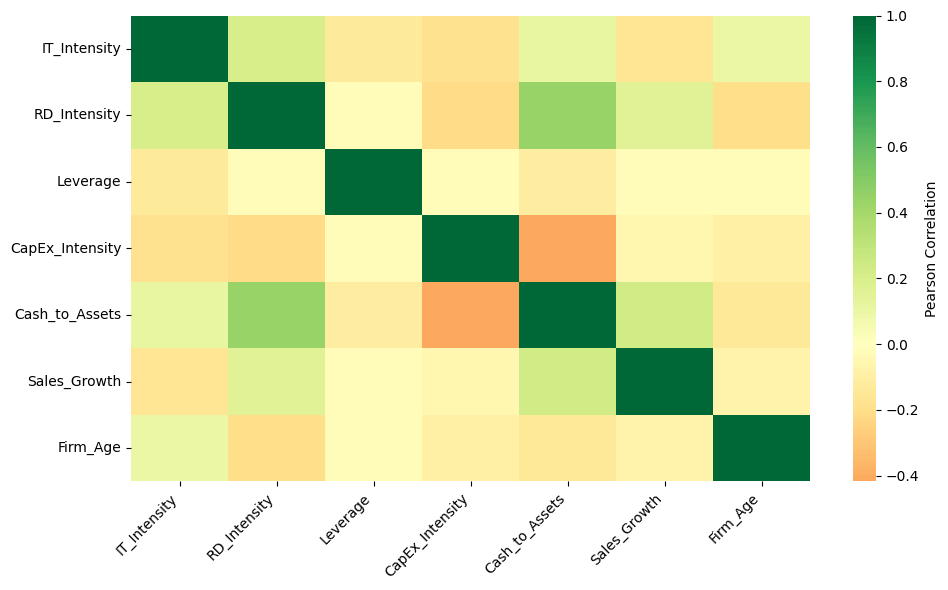

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant variables
cols = [
    "IT_Intensity", "RD_Intensity", "Leverage",
    "CapEx_Intensity", "Cash_to_Assets", "Sales_Growth", "Firm_Age"
]

# Calculate correlation matrix
corr_matrix = df[cols].corr()

# Create the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=False, cmap="RdYlGn", center=0,
            cbar_kws={"label": "Pearson Correlation"})
# plt.title("Correlation Heatmap: Profitability, IT, and R&D Variables")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

image_path = "C:\\Users\\leosh\\regression_result_table.png"
plt.savefig(image_path, dpi=300, bbox_inches='tight')

plt.show()

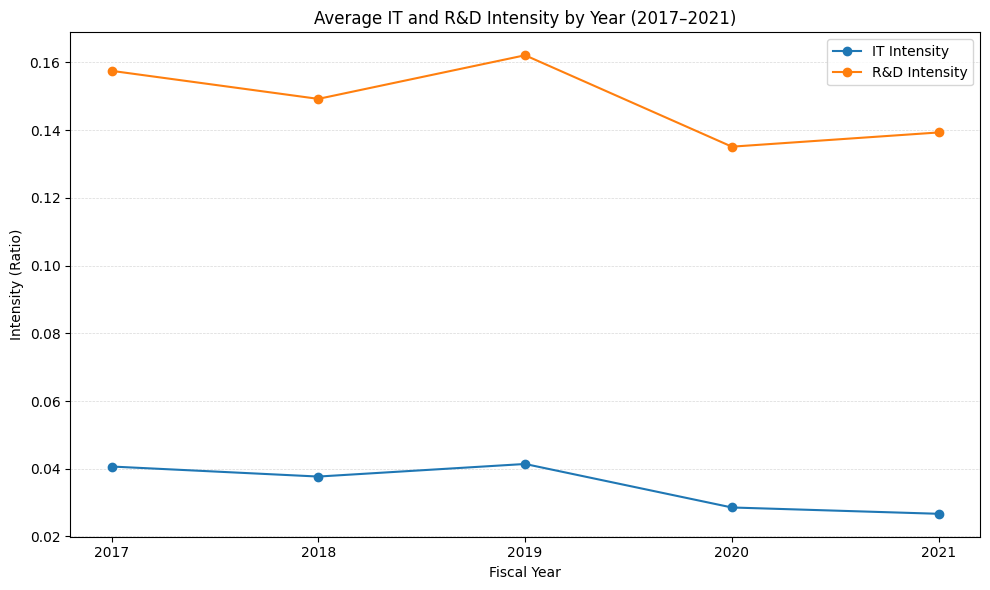

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

avg_by_year = df.groupby('Fiscal_Year')[['IT_Intensity', 'RD_Intensity']].mean().reset_index()

# Line plot
plt.figure(figsize=(10, 6))
plt.plot(avg_by_year['Fiscal_Year'], avg_by_year['IT_Intensity'], marker='o', label='IT Intensity')
plt.plot(avg_by_year['Fiscal_Year'], avg_by_year['RD_Intensity'], marker='o', label='R&D Intensity')

# Force x-axis ticks to be exactly these years
plt.xticks([2017, 2018, 2019, 2020, 2021])

# Labels and title
plt.title("Average IT and R&D Intensity by Year (2017–2021)")
plt.xlabel("Fiscal Year")
plt.ylabel("Intensity (Ratio)")
plt.grid(True, axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

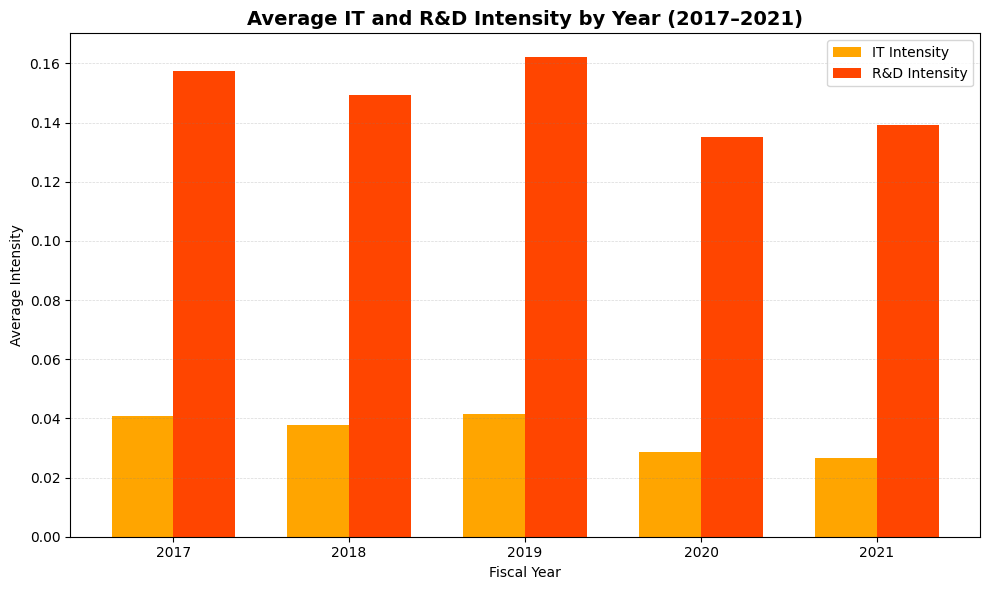

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

avg_by_year = df.groupby('Fiscal_Year')[['IT_Intensity', 'RD_Intensity']].mean().reset_index()

# Plot setup
x = avg_by_year['Fiscal_Year']
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, avg_by_year['IT_Intensity'], width, label='IT Intensity', color='orange')
ax.bar(x + width/2, avg_by_year['RD_Intensity'], width, label='R&D Intensity', color='orangered')

# Title and labels
ax.set_title('Average IT and R&D Intensity by Year (2017–2021)', fontsize=14, weight='bold')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Average Intensity')
ax.set_xticks(x)
ax.legend()

# Softer background grid
ax.grid(True, axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.3)

plt.tight_layout()
plt.show()

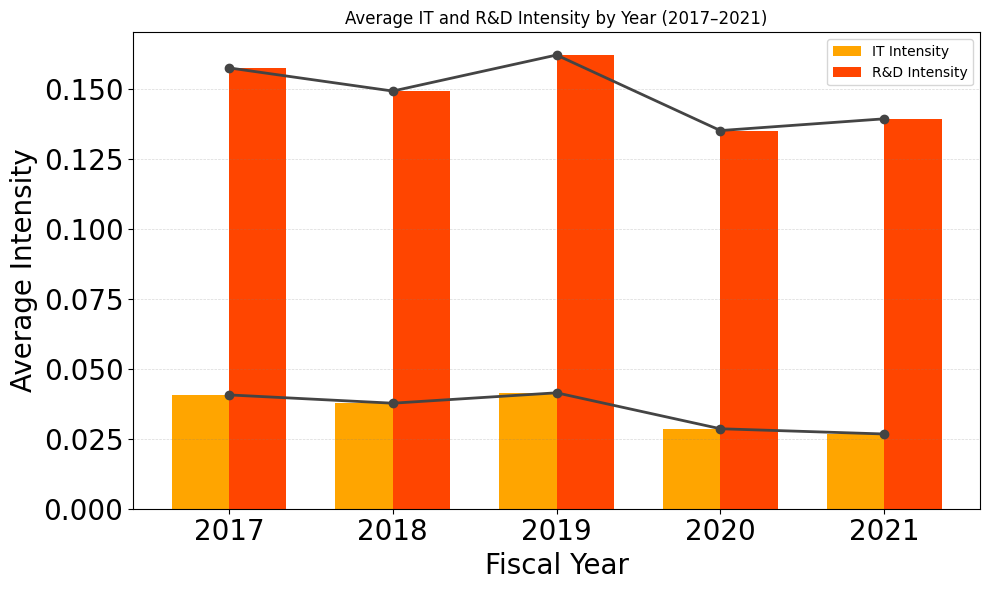

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and group data
avg_by_year = df.groupby('Fiscal_Year')[['IT_Intensity', 'RD_Intensity']].mean().reset_index()

x_labels = avg_by_year['Fiscal_Year']
x_pos = range(len(x_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
bars_it = ax.bar([p - width/2 for p in x_pos], avg_by_year['IT_Intensity'], width=width,
                 label='IT Intensity', color='orange')
bars_rd = ax.bar([p + width/2 for p in x_pos], avg_by_year['RD_Intensity'], width=width,
                 label='R&D Intensity', color='orangered')

# Plot trend lines in dark gray
ax.plot(x_pos, avg_by_year['IT_Intensity'], color='#444444', marker='o', linewidth=2)
ax.plot(x_pos, avg_by_year['RD_Intensity'], color='#444444', marker='o', linewidth=2)

# Format axes
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Fiscal Year', fontsize=20)
ax.set_ylabel('Average Intensity', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.set_title('Average IT and R&D Intensity by Year (2017–2021)')

# Grid and LEGEND (bar chart labels only)
ax.grid(True, axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.3)
ax.legend(loc='upper right')  # Only bar chart labels appear

plt.tight_layout()
plt.show()

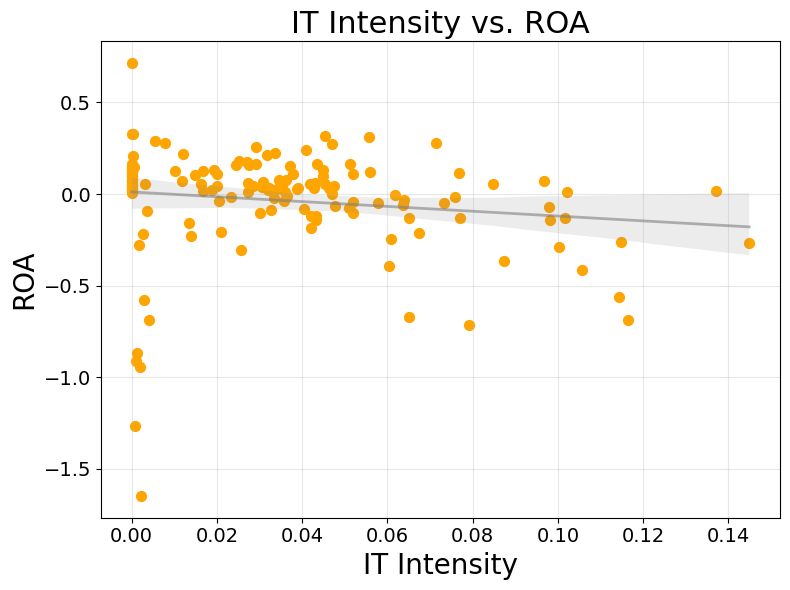

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(df['IT_Intensity'], df['ROA'], color='orange', s=50)  # s = marker size

# Optional: Add regression line
sns.regplot(x='IT_Intensity', y='ROA', data=df, scatter=False, color='gray', line_kws={'linewidth': 2, 'alpha': 0.6})

# Axis labels and title
plt.xlabel("IT Intensity", fontsize=20)
plt.ylabel("ROA", fontsize=20)
plt.title("IT Intensity vs. ROA", fontsize=22)

# Grid with soft styling
plt.grid(True, alpha=0.3)

plt.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

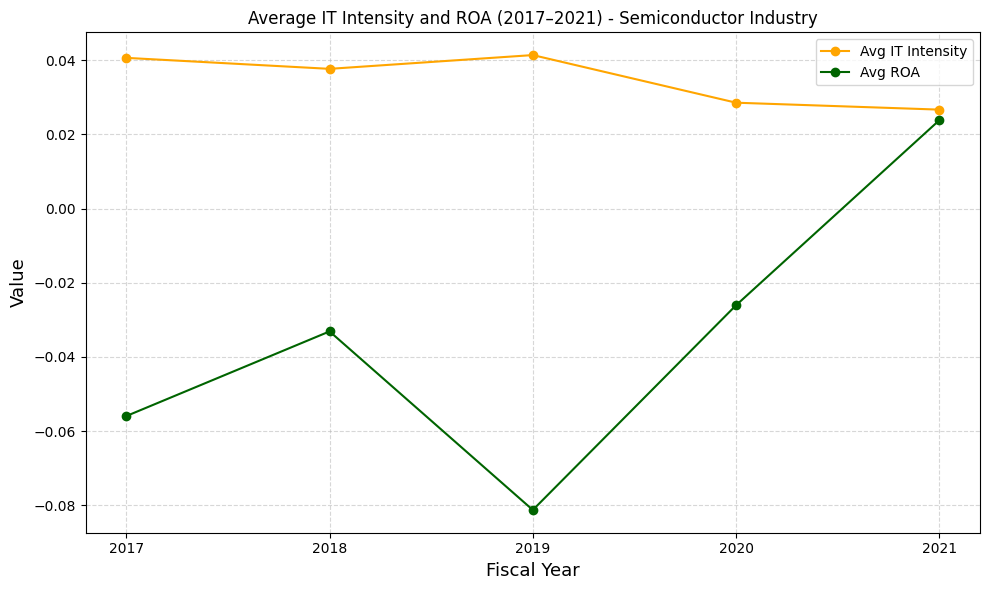

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv("final_version_2017-2021_semiconductor.csv")

# Group by year and calculate average IT Intensity and ROA
avg_by_year = df.groupby('Fiscal_Year')[['IT_Intensity', 'ROA']].mean().reset_index()

# Extract data
years = avg_by_year['Fiscal_Year']
avg_it = avg_by_year['IT_Intensity']
avg_roa = avg_by_year['ROA']

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(years, avg_it, marker='o', label='Avg IT Intensity', color='orange')
plt.plot(years, avg_roa, marker='o', label='Avg ROA', color='darkgreen')

# Customize
plt.title('Average IT Intensity and ROA (2017–2021) - Semiconductor Industry')
plt.xlabel('Fiscal Year', fontsize=13)
plt.ylabel('Value', fontsize=13)
plt.xticks(years)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()